In [4]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split


In [5]:
import pandas as pd

df = pd.read_pickle(
    r"C:\Users\moazz\Desktop\Earthquake_Project\dataset\df_train.csv"
)


### SOME REGULAR EDA(EXPLORATARY DATA ANALYSIS) TO GET TO KNOW WHAT KIND OF OUR REALLY IS 


In [6]:

df.shape

(34289, 45)

In [7]:
df.columns

Index(['level_0', 'index', 'E_channel', 'N_channel', 'E_channel_precursors',
       'N_channel_precursors', 'Z_channel_precursors', 'Z_channel',
       'back_azimuth_deg', 'coda_end_sample', 'network_code',
       'p_arrival_sample', 'p_status', 'p_travel_sec', 'p_weight',
       'receiver_code', 'receiver_elevation_m', 'receiver_latitude',
       'receiver_longitude', 'receiver_type', 's_arrival_sample', 's_status',
       's_weight', 'snr_db', 'source_depth_km', 'source_depth_uncertainty_km',
       'source_distance_deg', 'source_distance_km', 'source_error_sec',
       'source_gap_deg', 'source_horizontal_uncertainty_km', 'source_id',
       'source_latitude', 'source_longitude', 'source_magnitude',
       'source_magnitude_author', 'source_magnitude_type',
       'source_mechanism_strike_dip_rake', 'source_origin_time',
       'source_origin_uncertainty_sec', 'trace_category', 'trace_name',
       'trace_start_time', 'missing_time_from_event',
       'source_magnitude_label'],
    

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34289 entries, 0 to 34288
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   level_0                           34289 non-null  int64         
 1   index                             34289 non-null  int64         
 2   E_channel                         34289 non-null  object        
 3   N_channel                         34289 non-null  object        
 4   E_channel_precursors              34289 non-null  object        
 5   N_channel_precursors              34289 non-null  object        
 6   Z_channel_precursors              34289 non-null  object        
 7   Z_channel                         34289 non-null  object        
 8   back_azimuth_deg                  34289 non-null  object        
 9   coda_end_sample                   34289 non-null  object        
 10  network_code                      34289 non-nu

In [9]:
df.head()

,level_0,index,E_channel,N_channel,E_channel_precursors,N_channel_precursors,Z_channel_precursors,Z_channel,back_azimuth_deg,coda_end_sample,...,source_magnitude_author,source_magnitude_type,source_mechanism_strike_dip_rake,source_origin_time,source_origin_uncertainty_sec,trace_category,trace_name,trace_start_time,missing_time_from_event,source_magnitude_label
0,6000,2508,"[-0.0, -0.3037471, -0.7941901, -2.0677443, -2....","[-0.0, -0.1688106, -0.4445446, -1.1667616, -1....","[-174.67068, -160.9165, -111.053535, -55.44577...","[-165.62244, -131.0894, -92.94777, -50.196747,...","[34.627823, 6.5667224, -19.73172, -63.976402, ...","[-0.0, -0.040024515, -0.085517466, -0.22547446...",136.0,[[3199.0]],...,None,ml,None,2018-06-15 07:09:57.260,None,earthquake_local,HSSD.HV_20180615070953_EV,2018-06-15 07:09:54.030,-3.23,"[0, 0, 1, 0, 0]"
1,6001,177771,"[0.0, 0.008827989, 0.027690079, 0.050335042, 0...","[0.0, 0.0067506083, 0.017026894, 0.0626213, 0....","[11.102617, 20.359272, 22.870697, 9.638555, 11...","[18.403194, 5.542464, -8.4973955, -8.423143, 0...","[4.857739, 13.261822, 16.091331, 21.411762, 15...","[0.0, 0.0044994447, 0.012301209, 0.036946297, ...",204.300003,[[3097.0]],...,None,ml,None,2009-07-15 00:58:07.600,0.83,earthquake_local,CERT.IV_20090715005807_EV,2009-07-15 00:58:08.900,1.30,"[0, 0, 0, 1, 0]"
2,6002,143069,"[-0.0, -0.07114574, -0.07915803, 0.045831945, ...","[-0.0, -0.11352274, -0.40909925, -0.6154829, -...","[550.5055, 621.12805, 494.6476, 227.99667, -8....","[672.15076, 618.96216, 396.99496, 218.53148, 9...","[-51.757576, 128.74973, 153.27184, 69.25438, 4...","[-0.0, -0.02897907, 0.03212849, 0.31494758, 0....",46.099998,[[1928.0]],...,None,ml,None,2003-02-22 13:37:30.670,None,earthquake_local,SVD.CI_20030222133726_EV,2003-02-22 13:37:27.020,-3.65,"[0, 1, 0, 0, 0]"
3,6003,176271,"[-4.039773, -5.0321927, -3.098704, -2.0527992,...","[-1.1656461, -0.06951267, 2.7692225, 2.9919803...","[6.2956905, 10.219786, 5.2689557, -0.8171556, ...","[0.7568476, 2.7275038, 0.7710497, 2.6436691, 3...","[0.84727585, -0.23956358, -0.18065163, 3.83636...","[-0.33165205, -1.1276397, -0.23394835, -0.2988...",309.799988,[[2641.0]],...,None,ml,None,2018-07-26 18:46:42.410,None,earthquake_local,B084.PB_20180726184643_EV,2018-07-26 18:46:43.600,1.19,"[0, 0, 0, 1, 0]"
4,6004,44864,"[0.0, 0.0046114475, 0.01731589, 0.057890795, 0...","[-0.0, -0.008839174, -0.03844553, -0.08942565,...","[-42.98916, -48.740185, -76.14363, -64.10923, ...","[-28.852701, -9.431699, -17.502617, -8.581977,...","[30.556585, 10.862256, 45.766666, 30.64336, 17...","[0.0, 0.06398069, 0.17558555, 0.45652658, 0.61...",334.899994,[[3199.0]],...,None,ml,None,2013-03-13 22:34:50.480,0.82,earthquake_local,DOI.IV_20130313223451_EV,2013-03-13 22:34:52.420,1.94,"[0, 0, 1, 0, 0]"


In [10]:
type(df["Z_channel"].iloc[0])


numpy.ndarray

In [11]:
len(df["Z_channel"].iloc[0])


6000

In [12]:
df[["p_arrival_sample", "s_arrival_sample"]].head()


,p_arrival_sample,s_arrival_sample
0,898,1322.0
1,900,1730.0
2,900,1317.0
3,1000,1811.0
4,900,1677.0


In [13]:
df["Z_channel"].apply(len).value_counts()


Z_channel
6000    34289
Name: count, dtype: int64

### Plotting Only 1 Signal

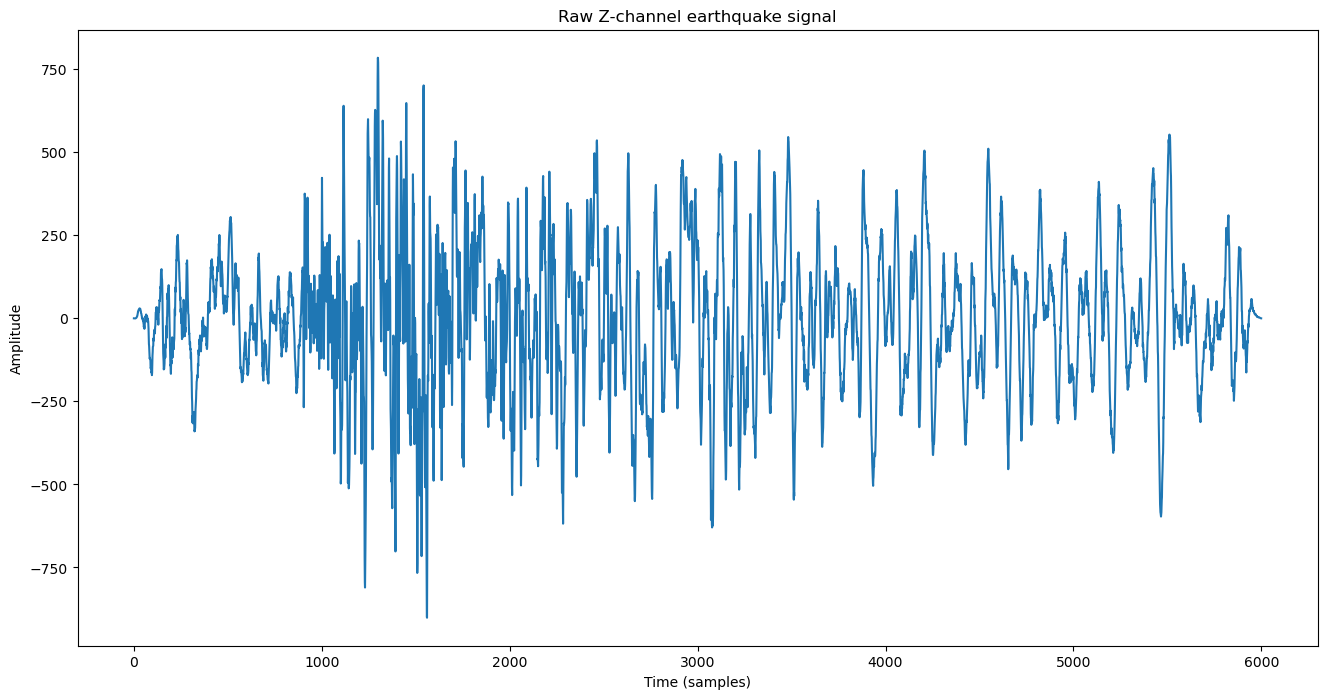

In [14]:
import matplotlib.pyplot as plt

signal = df["Z_channel"].iloc[0]

plt.figure(figsize=(16,8))
plt.plot(signal)
plt.title("Raw Z-channel earthquake signal")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.show()


#### In above figure we see that:
##### - X axis(0 ---> 6000) represent time moving forward(moment by moment)
##### - Y axis(Up and Down) represent up and down how much the ground moved up/down at that moment


### MARKING P and S arrival

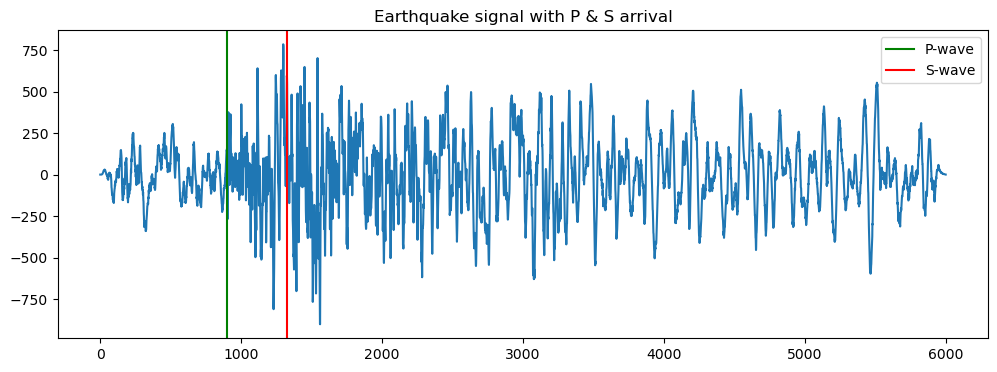

In [15]:
p = df["p_arrival_sample"].iloc[0]
s = df["s_arrival_sample"].iloc[0]

plt.figure(figsize=(12,4))
plt.plot(signal)
plt.axvline(p, color="green", label="P-wave")
plt.axvline(s, color="red", label="S-wave")
plt.legend()
plt.title("Earthquake signal with P & S arrival")
plt.show()



# For Baseline Model (Regression Model)


In [16]:
# Scipy is a scientific library of python,Signal is subset of that library for waves/signals ,butter creates a butterworth filter(a kind
# of filter ) filfit applies the filter backward + forward

from scipy.signal import butter, filtfilt

# sr is sampling rate low removes anything below 1hz high remove anything above 20hz, simplest idea keep shaking between 1-20 hz throw away
# rest of the shit

def bandpass_filter(signal, sr=100, low=1, high=20):
    nyqf = 0.5 * sr #nyqf is Nyquist Frequency(hald of sampling rate) by half cuz signals from the system can only be trusted upto half the sr rate
    
#creating the filter
    b, a = butter(
        N=4, # it defines the sharpness of the filter
        Wn=[low/nyqf, high/nyqf],
        btype="band"
    )
    return filtfilt(b, a, signal)


In [17]:
# Applying filter to 1 Signal
Raw_Sig = df["Z_channel"].iloc[0]
filt_sig = bandpass_filter(Raw_Sig)


In [18]:
# Normalizing the signal
import numpy as np

# This function make all the signal values small and controlled

def normalize(signal):
    max_val = np.max(np.abs(signal))
    if max_val == 0:
        return signal  # keep zero signal as-is
    return signal / max_val


# np.abs(signal) - convert all the values to positive
#np.max(np.abs(signal)) - Find the largest value in the Signal




clean_sig = normalize(filt_sig)


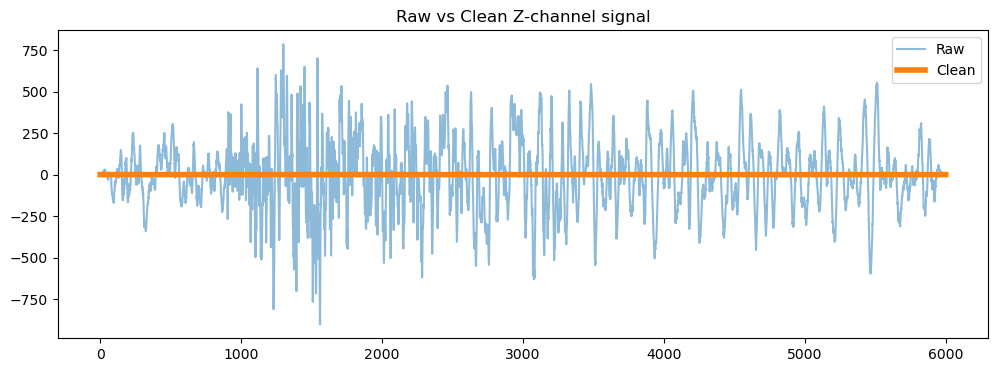

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(Raw_Sig, label="Raw", alpha=0.5)
plt.plot(clean_sig, label="Clean", linewidth=4)
plt.legend()
plt.title("Raw vs Clean Z-channel signal")
plt.show()


In [20]:
#Applying Preprocessing on the whole dataset

def preprocess_signal(signal):
    signal = bandpass_filter(signal)
    signal = normalize(signal)
    return signal

X = np.stack(df["Z_channel"].apply(preprocess_signal).values)

y = df[["p_arrival_sample", "s_arrival_sample"]].values


In [21]:
def extract_features(signal):
    return [
        np.mean(signal),          # average movement
        np.std(signal),           # how shaky-shaky it is
        np.max(signal),           # strongest upward movement
        np.min(signal),           # strongest downward movement
        np.sum(signal**2)         # total energy
    ]


In [22]:
X_new = np.array(
    df["Z_channel"].apply(extract_features).tolist()
)


In [23]:
X_new.shape


(34289, 5)

In [24]:
y_new = df[["p_arrival_sample", "s_arrival_sample"]].values


In [25]:

from sklearn.model_selection import train_test_split

Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42
)

# 🔥 USE SMALLER DATA (ADD HERE)
Xb_train = Xb_train[:8000]
yb_train = yb_train[:8000]


In [26]:
from sklearn.ensemble import RandomForestRegressor

baseline_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(Xb_train, yb_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import precision_score, recall_score, accuracy_score

preds = baseline_model.predict(Xb_val)

mae_p = mean_absolute_error(yb_val[:,0], preds[:,0])
mae_s = mean_absolute_error(yb_val[:,1], preds[:,1])

print("Baseline MAE (P-wave):", mae_p)
print("Baseline MAE (S-wave):", mae_s)


Baseline MAE (P-wave): 38.617433654126565
Baseline MAE (S-wave): 268.4942905069809


# PreProcessing

In [28]:
# 1. Drop rows with bad labels
df = df.dropna(subset=["p_arrival_sample", "s_arrival_sample"])

# 2. Remove zero-only signals
df = df[df["Z_channel"].apply(lambda x: np.max(np.abs(x)) > 0)]

print("After cleaning:", len(df))


After cleaning: 34287


In [29]:
TARGET_LEN = 6000  # use your real length

def fix_length(sig):
    if len(sig) > TARGET_LEN:
        return sig[:TARGET_LEN]
    if len(sig) < TARGET_LEN:
        return np.pad(sig, (0, TARGET_LEN - len(sig)))
    return sig

df["Z_channel"] = df["Z_channel"].apply(fix_length)


In [30]:
def normalize_signal(sig):
    max_val = np.max(np.abs(sig))
    if max_val == 0:
        return sig
    return sig / max_val

df["Z_channel"] = df["Z_channel"].apply(normalize_signal)


In [31]:
from scipy.signal import spectrogram

def get_spectrogram(signal):
    f, t, Sxx = spectrogram(signal, fs=100)
    return Sxx

df["Z_spec"] = df["Z_channel"].apply(get_spectrogram)
df["N_spec"] = df["N_channel"].apply(get_spectrogram)
df["E_spec"] = df["E_channel"].apply(get_spectrogram)

In [32]:
# ----- preprocessing complete -----

# 🔥 1) Station-based split FIRST
stations = df["receiver_code"].unique()

np.random.seed(42)
np.random.shuffle(stations)

n_total = len(stations)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)

train_stations = stations[:n_train]
val_stations   = stations[n_train:n_train+n_val]
test_stations  = stations[n_train+n_val:]

df_train = df[df["receiver_code"].isin(train_stations)]
df_val   = df[df["receiver_code"].isin(val_stations)]
df_test  = df[df["receiver_code"].isin(test_stations)]


In [33]:
X_train = np.array(df_train["Z_channel"].to_list(), dtype=np.float32)
y_train = df_train[["p_arrival_sample", "s_arrival_sample"]].to_numpy(dtype=np.float32)

X_val = np.array(df_val["Z_channel"].to_list(), dtype=np.float32)
y_val = df_val[["p_arrival_sample", "s_arrival_sample"]].to_numpy(dtype=np.float32)

X_test = np.array(df_test["Z_channel"].to_list(), dtype=np.float32)
y_test = df_test[["p_arrival_sample", "s_arrival_sample"]].to_numpy(dtype=np.float32)

# 🔥 REDUCE SIGNAL LENGTH (ADD HERE)
X_train = X_train[:, :2000]
X_val   = X_val[:, :2000]
X_test  = X_test[:, :2000]

In [34]:
signal_length = X_train.shape[1]

y_train = y_train / signal_length
y_val   = y_val   / signal_length
y_test  = y_test  / signal_length

In [35]:
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )




In [36]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_val   = X_val[:, None, :]
X_test  = X_test[:, None, :]

In [37]:
from scipy.signal import spectrogram

def compute_spectrogram_batch(X):
    specs = []
    for sig in X:
        f, t, Sxx = spectrogram(sig, fs=100)
        specs.append(Sxx)
    return np.array(specs)

X_train_spec = compute_spectrogram_batch(X_train)
X_val_spec   = compute_spectrogram_batch(X_val)
X_test_spec  = compute_spectrogram_batch(X_test)

In [38]:
# ===== TIME DOMAIN =====
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32)


# ===== FREQUENCY DOMAIN =====
# 🔥 SAFE CHECK (prevents your error forever)

if len(X_train_spec.shape) == 3:
    X_train_spec = X_train_spec[:, None, :, :]

if len(X_val_spec.shape) == 3:
    X_val_spec = X_val_spec[:, None, :, :]

if len(X_test_spec.shape) == 3:
    X_test_spec = X_test_spec[:, None, :, :]

X_train_spec_t = torch.tensor(X_train_spec, dtype=torch.float32)
X_val_spec_t   = torch.tensor(X_val_spec, dtype=torch.float32)
X_test_spec_t  = torch.tensor(X_test_spec, dtype=torch.float32)

In [39]:
train_ds = TensorDataset(X_train_t, X_train_spec_t, y_train_t)
val_ds   = TensorDataset(X_val_t, X_val_spec_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

In [40]:
class SeismicModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn_time = nn.Sequential(
            nn.Conv1d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.cnn_freq = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # 🔥 UPDATED (input = 32 + 32 after concat)
        self.lstm = nn.LSTM(64, 64, batch_first=True, bidirectional=True)

        self.attn = nn.Linear(128, 1)
        self.fc = nn.Linear(128, 2)

    def forward(self, x_time, x_freq):
        # ----- TIME BRANCH -----
        t = self.cnn_time(x_time)   # (B, 32, L)

        # ----- FREQ BRANCH -----
        f = self.cnn_freq(x_freq)   # (B, 32, H, W)
        f = f.view(f.size(0), f.size(1), -1)  # (B, 32, N)

        # 🔥 MATCH LENGTH
        f = torch.nn.functional.adaptive_avg_pool1d(f, t.size(2))  # (B, 32, L)

        # 🔥 FUSION (CORRECT)
        x = torch.cat([t, f], dim=1)  # (B, 64, L)

        # ----- LSTM -----
        x = x.permute(0, 2, 1)  # (B, L, 64)
        x, _ = self.lstm(x)     # (B, L, 128)

        # ----- ATTENTION -----
        weights = torch.softmax(self.attn(x), dim=1)
        x = (weights * x).sum(dim=1)  # (B, 128)

        # ----- OUTPUT -----
        return self.fc(x)

In [41]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SeismicModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [42]:
train_losses = []
val_losses = []

In [44]:
epochs = 5
for epoch in range(epochs):
    
    print(f"\n🚀 Starting Epoch {epoch+1}/{epochs}")   # ✅ MOVE HERE

    model.train()
    train_loss = 0
    

    for batch_idx, (xb_time, xb_freq, yb) in enumerate(train_loader):
        xb_time = xb_time.to(device)
        xb_freq = xb_freq.to(device)
        yb = yb.to(device)

        # shape fix
        if xb_time.dim() == 4:
            xb_time = xb_time.squeeze(2)

        if xb_freq.dim() == 5:
            xb_freq = xb_freq.squeeze(2)

        optimizer.zero_grad()

        preds = model(xb_time, xb_freq)

        # losses
        data_loss = criterion(preds, yb)

        p_pred = preds[:, 0]
        s_pred = preds[:, 1]
        phys_loss = torch.mean(torch.relu(p_pred - s_pred))

        loss = data_loss + 0.1 * phys_loss

        loss.backward()
        optimizer.step()
        

        train_loss += loss.item()

        # 🔥 batch print
        if batch_idx % 50 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx} | Loss: {loss.item():.4f}")
        

    # 🔥 epoch summary (VERY IMPORTANT)
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f}")


🚀 Starting Epoch 1/5
Epoch 1 | Batch 0 | Loss: 0.0083
Epoch 1 | Batch 50 | Loss: 0.0058
Epoch 1 | Batch 100 | Loss: 0.0171
Epoch 1 | Batch 150 | Loss: 0.0070
Epoch 1 | Batch 200 | Loss: 0.0077
Epoch 1 | Batch 250 | Loss: 0.0058
Epoch 1 | Batch 300 | Loss: 0.0058
Epoch 1 | Batch 350 | Loss: 0.0105
Epoch 1 | Batch 400 | Loss: 0.0108
Epoch 1 | Batch 450 | Loss: 0.0064
Epoch 1 | Batch 500 | Loss: 0.0107
Epoch 1 | Batch 550 | Loss: 0.0034
Epoch 1 | Batch 600 | Loss: 0.0052
Epoch 1 | Batch 650 | Loss: 0.0059
Epoch 1 | Batch 700 | Loss: 0.0124
Epoch 1 | Batch 750 | Loss: 0.0113
Epoch 1/5 | Train Loss: 0.0082

🚀 Starting Epoch 2/5
Epoch 2 | Batch 0 | Loss: 0.0087
Epoch 2 | Batch 50 | Loss: 0.0057
Epoch 2 | Batch 100 | Loss: 0.0064
Epoch 2 | Batch 150 | Loss: 0.0108
Epoch 2 | Batch 200 | Loss: 0.0111
Epoch 2 | Batch 250 | Loss: 0.0081
Epoch 2 | Batch 300 | Loss: 0.0077
Epoch 2 | Batch 350 | Loss: 0.0065
Epoch 2 | Batch 400 | Loss: 0.0102
Epoch 2 | Batch 450 | Loss: 0.0056
Epoch 2 | Batch 500 |

In [45]:
# Move to device
X_val_t = X_val_t.to(device)
X_val_spec_t = X_val_spec_t.to(device)

# 🔥 FIX SHAPES (VERY IMPORTANT)
if X_val_t.dim() == 4:
    X_val_t = X_val_t.squeeze(2)

if X_val_spec_t.dim() == 5:
    X_val_spec_t = X_val_spec_t.squeeze(2)

# Inference
with torch.no_grad():
    preds = model(X_val_t, X_val_spec_t).cpu().numpy()


# -------------------------------
# Regression Metrics (MAE)
# -------------------------------

pred_samples = preds * signal_length
true_samples = y_val * signal_length

mae = np.mean(np.abs(pred_samples - true_samples), axis=0)

print("P MAE:", mae[0], "samples")
print("S MAE:", mae[1], "samples")


# -------------------------------
# Classification Metrics (FIXED)
# -------------------------------

tolerance = 50

correct_p = np.abs(pred_samples[:, 0] - true_samples[:, 0]) <= tolerance
correct_s = np.abs(pred_samples[:, 1] - true_samples[:, 1]) <= tolerance

y_pred_p = correct_p.astype(int)
y_pred_s = correct_s.astype(int)

# ⚠️ IMPORTANT FIX HERE
# ground truth should be "correctness"
y_true_p = np.ones_like(y_pred_p)
y_true_s = np.ones_like(y_pred_s)

# Metrics
precision_p = precision_score(y_true_p, y_pred_p, zero_division=0)
recall_p = recall_score(y_true_p, y_pred_p, zero_division=0)
accuracy_p = accuracy_score(y_true_p, y_pred_p)

precision_s = precision_score(y_true_s, y_pred_s, zero_division=0)
recall_s = recall_score(y_true_s, y_pred_s, zero_division=0)
accuracy_s = accuracy_score(y_true_s, y_pred_s)

print("\n--- P Wave Metrics ---")
print("Precision:", precision_p)
print("Recall:", recall_p)
print("Accuracy:", accuracy_p)

print("\n--- S Wave Metrics ---")
print("Precision:", precision_s)
print("Recall:", recall_s)
print("Accuracy:", accuracy_s)

P MAE: 42.54332 samples
S MAE: 119.99546 samples

--- P Wave Metrics ---
Precision: 1.0
Recall: 0.7085086489013558
Accuracy: 0.7085086489013558

--- S Wave Metrics ---
Precision: 1.0
Recall: 0.3747078073866293
Accuracy: 0.3747078073866293


In [52]:
torch.save(model.state_dict(), "training_model_2.pth")

## SOME VISUALIZATIONS


In [50]:
train_losses = [0.0082, 0.0072, 0.0054, 0.0048, 0.0044]

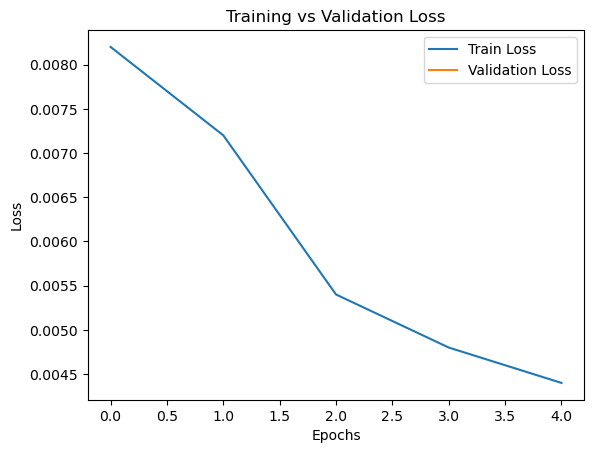

In [51]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.savefig("loss_curve.png")
plt.show()

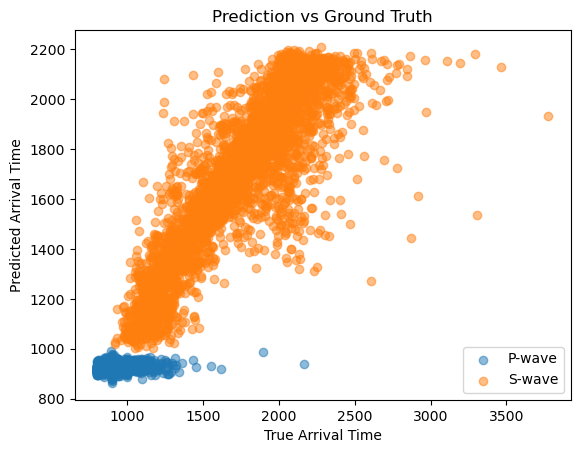

In [47]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(true_samples[:, 0], pred_samples[:, 0], alpha=0.5, label="P-wave")
plt.scatter(true_samples[:, 1], pred_samples[:, 1], alpha=0.5, label="S-wave")

plt.xlabel("True Arrival Time")
plt.ylabel("Predicted Arrival Time")
plt.legend()
plt.title("Prediction vs Ground Truth")
plt.savefig("prediction_vs_true.png")
plt.show()

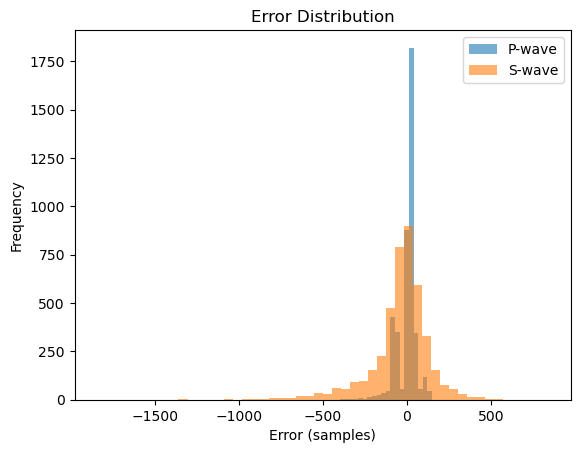

In [48]:
errors_p = pred_samples[:, 0] - true_samples[:, 0]
errors_s = pred_samples[:, 1] - true_samples[:, 1]

plt.figure()
plt.hist(errors_p, bins=50, alpha=0.6, label="P-wave")
plt.hist(errors_s, bins=50, alpha=0.6, label="S-wave")

plt.xlabel("Error (samples)")
plt.ylabel("Frequency")
plt.legend()
plt.title("Error Distribution")
plt.savefig("error_distribution.png")
plt.show()